In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sales_df = pd.read_csv(r"C:\Users\Dell\Downloads\sales_data.csv")
customers_df = pd.read_csv(r"C:\Users\Dell\Downloads\customer_churn.csv")

print(sales_df.head())
print(customers_df.head())

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Elec

In [16]:
sales_df.info()
customers_df.info()

sales_df.isnull().sum()
customers_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         100 non-null    datetime64[ns]
 1   Product      100 non-null    object        
 2   Quantity     100 non-null    int64         
 3   Price        100 non-null    int64         
 4   Customer_ID  100 non-null    object        
 5   Region       100 non-null    object        
 6   Total_Sales  100 non-null    int64         
 7   Year         100 non-null    int32         
 8   Month        100 non-null    int32         
dtypes: datetime64[ns](1), int32(2), int64(3), object(3)
memory usage: 6.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null  

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Sales Dataset Columns:
['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']

Customer Dataset Columns:
['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn']

Sales Dataset Sample:
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680

Customer Dataset Sample:
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27      

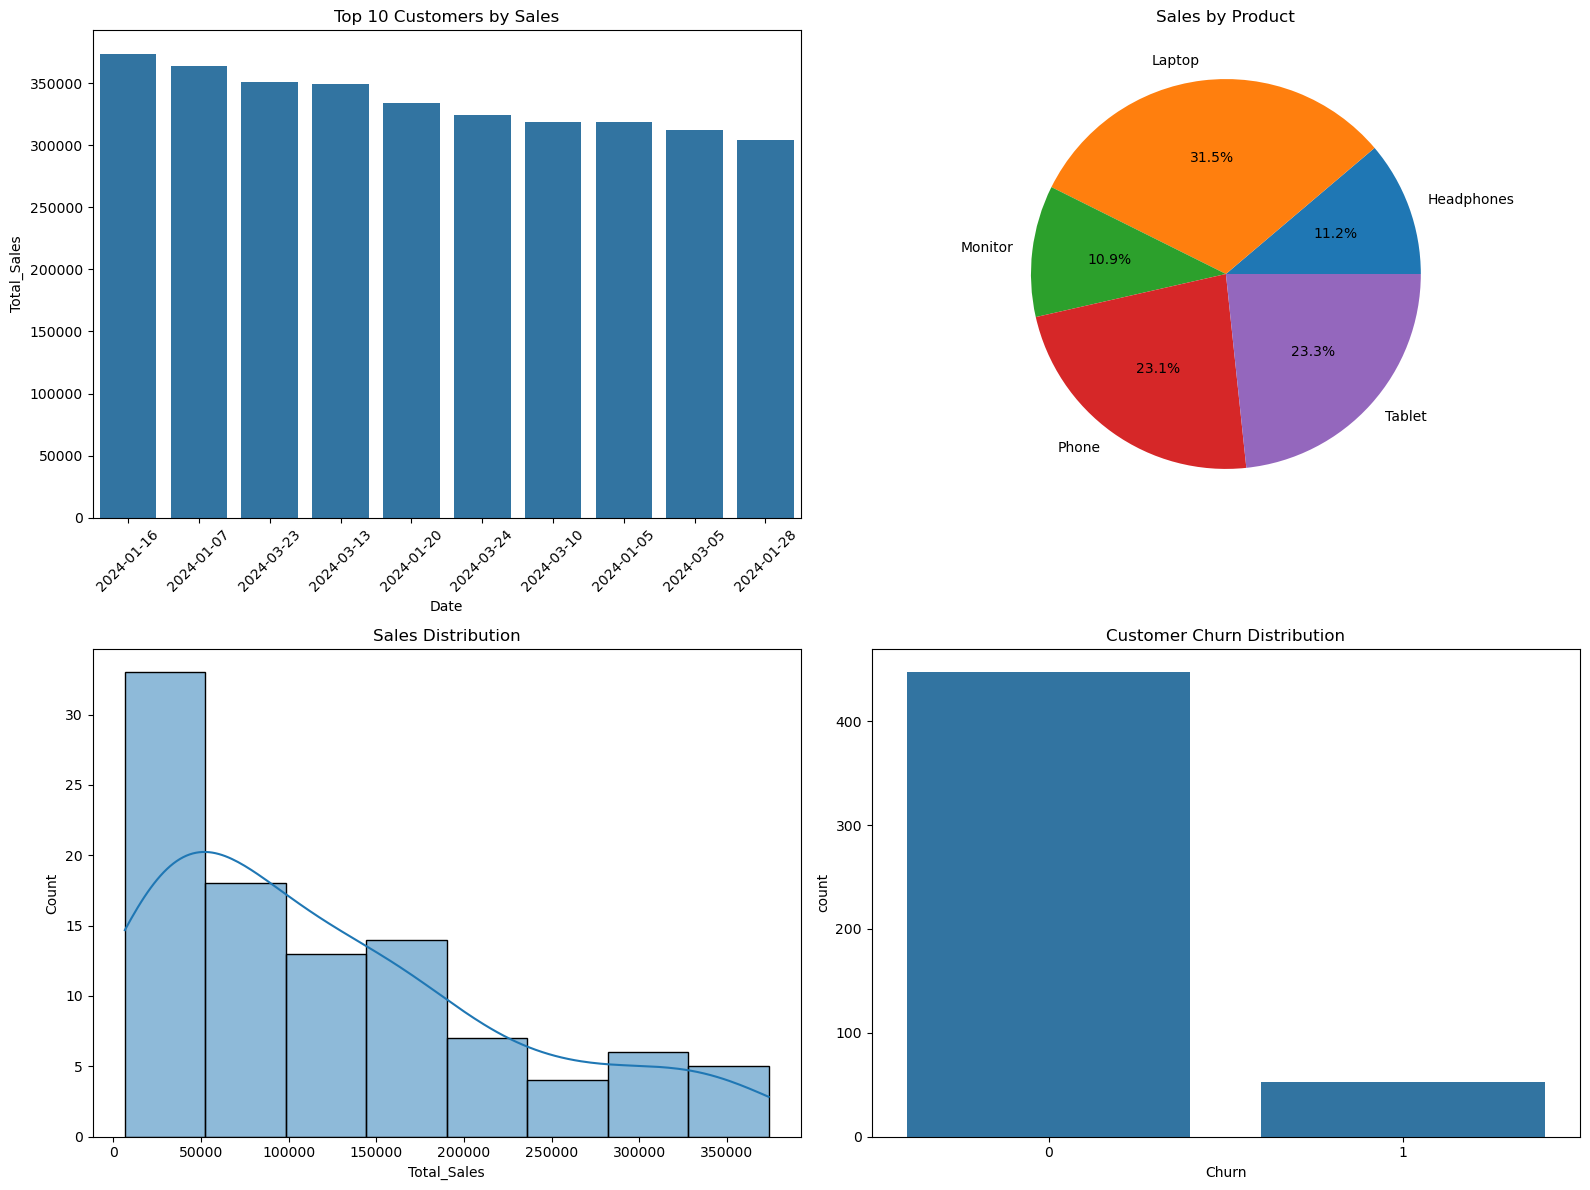

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
sales_df = pd.read_csv(r"C:\Users\Dell\Downloads\sales_data.csv")
customers_df = pd.read_csv(r"C:\Users\Dell\Downloads\customer_churn.csv")

# Display dataset information
print("Sales Dataset Columns:")
print(sales_df.columns.tolist())

print("\nCustomer Dataset Columns:")
print(customers_df.columns.tolist())

print("\nSales Dataset Sample:")
print(sales_df.head())

print("\nCustomer Dataset Sample:")
print(customers_df.head())

# ---------------------------------------
# Replace these column names if needed
# ---------------------------------------
customer_col = sales_df.columns[0]      # Customer column
product_col = sales_df.columns[1]       # Product column
sales_col = sales_df.columns[-1]        # Sales column

# Create Figure
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------------------------------
# 1. Top Customers by Sales
# ---------------------------------------
top_customers = (
    sales_df.groupby(customer_col)[sales_col]
    .sum()
    .reset_index()
    .sort_values(by=sales_col, ascending=False)
    .head(10)
)

sns.barplot(
    data=top_customers,
    x=customer_col,
    y=sales_col,
    ax=axes[0,0]
)

axes[0,0].set_title("Top 10 Customers by Sales")
axes[0,0].tick_params(axis='x', rotation=45)

# ---------------------------------------
# 2. Sales by Product
# ---------------------------------------
product_sales = (
    sales_df.groupby(product_col)[sales_col]
    .sum()
)

axes[0,1].pie(
    product_sales,
    labels=product_sales.index,
    autopct='%1.1f%%'
)

axes[0,1].set_title("Sales by Product")

# ---------------------------------------
# 3. Sales Distribution
# ---------------------------------------
sns.histplot(
    sales_df[sales_col],
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title("Sales Distribution")

# ---------------------------------------
# 4. Customer Churn Distribution
# ---------------------------------------
churn_col = customers_df.columns[-1]

sns.countplot(
    x=churn_col,
    data=customers_df,
    ax=axes[1,1]
)

axes[1,1].set_title("Customer Churn Distribution")

plt.tight_layout()
plt.show()